# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [143]:
# Data is from 17 different marketing campaigns betwen May 2008 and Nov 2010

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [145]:
df = pd.read_csv('bank-additional-full.csv', sep = ';')

In [146]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [147]:
# 1.Let's examine and clean the data here



# 2. Columns we expect to be categorical
cat_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
    "y",
]

# 3. Treat 'unknown' as missing for these columns
unknown_as_missing = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
]

for col in unknown_as_missing:
    df[col] = df[col].replace("unknown", np.nan)

# 4. Recode pdays: 999 means "not previously contacted" → set to NaN
df["pdays"] = df["pdays"].replace(999, np.nan)

# 5. Convert object → category (more memory-efficient, clearer intent)
for col in cat_cols:
    df[col] = df[col].astype("category")

# 6. Drop/leakage handling: duration should NOT be used for a realistic model
# Comment this out if you're just benchmarking and want to keep it
df_model = df.drop(columns=["duration"])

# 7. Encode target: y = 'yes' → 1, 'no' → 0
df_model["y"] = df_model["y"].map({"yes": 1, "no": 0})

# 8. Quick checks
print("Missing values per column:")
print(df_model.isna().sum().sort_values(ascending=False))

print("\nDtypes:")
print(df_model.dtypes)


Missing values per column:
pdays             39673
default            8597
education          1731
loan                990
housing             990
job                 330
marital              80
age                   0
contact               0
month                 0
day_of_week           0
campaign              0
previous              0
poutcome              0
emp.var.rate          0
cons.price.idx        0
cons.conf.idx         0
euribor3m             0
nr.employed           0
y                     0
dtype: int64

Dtypes:
age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
campaign             int64
pdays              float64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m   

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int64   
 1   job             40858 non-null  category
 2   marital         41108 non-null  category
 3   education       39457 non-null  category
 4   default         32591 non-null  category
 5   housing         40198 non-null  category
 6   loan            40198 non-null  category
 7   contact         41188 non-null  category
 8   month           41188 non-null  category
 9   day_of_week     41188 non-null  category
 10  duration        41188 non-null  int64   
 11  campaign        41188 non-null  int64   
 12  pdays           1515 non-null   float64 
 13  previous        41188 non-null  int64   
 14  poutcome        41188 non-null  category
 15  emp.var.rate    41188 non-null  float64 
 16  cons.price.idx  41188 non-null  float64 
 17  cons.conf.id

In [149]:
# Business Objective
# To improve the efficiency and success rate of the bank’s direct marketing campaigns 
# by using data mining techniques to identify which clients are most likely to subscribe 
# to a long-term deposit product, thereby reducing unnecessary contacts and optimizing marketing resources.


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [150]:
# Dataset Feature Overview
# -----------------------
# This table documents the key features in our banking dataset:
#
# Personal/Demographic Features:
# - age: Numeric value representing client's age in years
# - marital: Client's marital status (married/single/divorced/unknown)
# - education: Client's highest education level achieved
# - job: Client's type of employment/occupation
#
# Financial/Banking Features:
# - default: Whether client has defaulted on credit (yes/no/unknown)
# - balance: Client's account balance (annual or average)
# - housing: Whether client has a housing loan (yes/no/unknown)
# - loan: Whether client has a personal loan (yes/no/unknown)
#
# Target Variable:
# - y: Whether client subscribed to a term deposit (yes/no) - this is what we're trying to predict

In [151]:
# Import libraries here

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [153]:
# helper to convert y to 0/1 for AUC
def to_binary(y):
    return (y == "yes").astype(int)

In [154]:
# Let's store data in a list for reporting later
results = []

In [155]:
# Select features and target
# bank/client info + duration + previous outcome
selected_features = [
    'age',        # numeric
    'job',        # categorical
    'marital',    # categorical
    'education',  # categorical
    'default',    # categorical
    'housing',    # categorical
    'loan',       # categorical
    'duration',   # numeric (call duration for this contact)
    'poutcome'    # categorical (outcome of previous marketing campaign)
]
target = 'y'      # yes/no

X = df[selected_features]
y = df[target]

# Separate numeric and categorical columns
num_features = ['age', 'duration']
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']

# Define the transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Column transformer to apply to the right columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)



### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [156]:
#  Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [157]:
# Fit the preprocessor on train, transform train and test
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [158]:

# Validate print shapes to verify
print("X_train_enc shape:", X_train_enc.shape)
print("X_test_enc shape:", X_test_enc.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))

X_train_enc shape: (28831, 32)
X_test_enc shape: (12357, 32)
y_train distribution:
 y
no     0.887343
yes    0.112657
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [159]:

# 1) Define the baseline model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Most frequent baseline (always predicts majority class)
start = time.time()
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_enc, y_train)
train_time = time.time() - start

y_pred_train = dummy.predict(X_train_enc)
y_pred_test = dummy.predict(X_test_enc)
# dummy may not expose proba for both classes if only one class in train,
# but in this dataset we have both, so it's fine:
y_proba_test = dummy.predict_proba(X_test_enc)[:, 1]

results.append({
    "Model": "Dummy (most_frequent)",
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(to_binary(y_test), y_proba_test),
    "Training Time (s)": train_time
})


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

Training Accuracy: 0.9045
Test Accuracy:     0.9051
ROC-AUC:           0.876
Training Time:     1.0465 seconds

Confusion Matrix:
[[10965     0]
 [ 1392     0]]

Classification Report:
              precision    recall  f1-score   support

          no      0.887     1.000     0.940     10965
         yes      0.000     0.000     0.000      1392

    accuracy                          0.887     12357
   macro avg      0.444     0.500     0.470     12357
weighted avg      0.787     0.887     0.834     12357

Training Time Regression: 1.0465 seconds



/Users/vinodkasturi/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/vinodkasturi/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/vinodkasturi/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

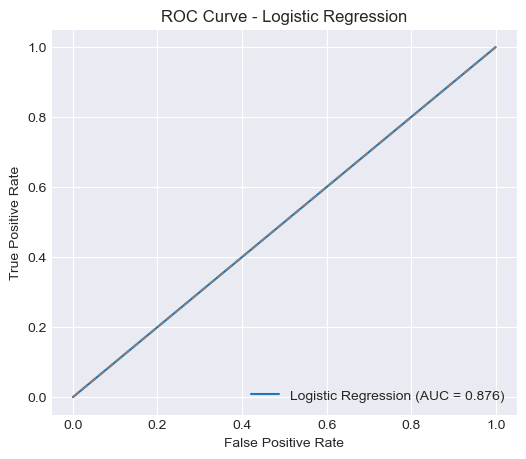

[{'Model': 'Dummy (most_frequent)', 'Train Accuracy': 0.8873434844438278, 'Test Accuracy': 0.8873512988589464, 'ROC-AUC': np.float64(0.5), 'Training Time (s)': 0.017094850540161133}, {'Model': 'Logistic Regression', 'Training Time (s)': 1.0465290546417236, 'Train Accuracy': 0.9044778190142555, 'Test Accuracy': 0.9050740470988103, 'ROC-AUC': np.float64(0.8758708154472695)}]


In [160]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import time

# Define and train the model
start_time_regression = time.time()
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_enc, y_train)
train_time_regression = time.time()-start_time_regression


# Make predictions
y_pred_train = log_reg.predict(X_train_enc)
y_pred_test = log_reg.predict(X_test_enc)
y_proba_test = log_reg.predict_proba(X_test_enc)[:, 1]

# Accuracy Scores
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

# Convert target to binary (1 for yes, 0 for no)
y_test_binary = (y_test == 'yes').astype(int)

#AUC
roc_auc = roc_auc_score((y_test == "yes").astype(int), y_proba_test)


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"ROC-AUC:           {roc_auc:.3f}")
print(f"Training Time:     {train_time_regression:.4f} seconds\n")
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"Training Time Regression: {train_time_regression:.4f} seconds\n")



# Metrics
results.append({
    "Model": "Logistic Regression",
    "Training Time (s)": train_time_regression,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})

# 4️⃣ Plot ROC curve
fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

print(results)

### Problem 9: Score the Model

What is the accuracy of your model?

In [161]:
print(results)

[{'Model': 'Dummy (most_frequent)', 'Train Accuracy': 0.8873434844438278, 'Test Accuracy': 0.8873512988589464, 'ROC-AUC': np.float64(0.5), 'Training Time (s)': 0.017094850540161133}, {'Model': 'Logistic Regression', 'Training Time (s)': 1.0465290546417236, 'Train Accuracy': 0.9044778190142555, 'Test Accuracy': 0.9050740470988103, 'ROC-AUC': np.float64(0.8758708154472695)}]


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [162]:
# Let's try KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# KNN works better when features are on a similar scale.
# Our encoded features are sparse, so we use StandardScaler(with_mean=False)
start_time = time.time()
knn = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("knn", KNeighborsClassifier(n_neighbors=5,  # you can tune this
                                 weights='distance',  # helps a bit
                                 n_jobs=-1))
])

# Fit on the encoded training data
knn.fit(X_train_enc, y_train)
train_time_knn = time.time() - start_time

#print(train_time_knn)
# Predictions
y_pred_train = knn.predict(X_train_enc)
y_pred_test = knn.predict(X_test_enc)
y_proba_test = knn.predict_proba(X_test_enc)[:, 1]

# Metrics
results.append({
    "Model": "KNN (k=5)",
    "Training Time (s)": train_time_knn,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})




In [163]:
# Decision Tree
# ===== Decision Tree =====
from sklearn.tree import DecisionTreeClassifier

start = time.time()
tree = DecisionTreeClassifier(max_depth=5, random_state=42)  # you can tune depth later
tree.fit(X_train_enc, y_train)
train_time = time.time() - start

# Predictions
y_pred_train = tree.predict(X_train_enc)
y_pred_test = tree.predict(X_test_enc)
y_proba_test = tree.predict_proba(X_test_enc)[:, 1]

results.append({
    "Model": "Decision Tree (max_depth=5)",
    "Training Time (s)": train_time,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(to_binary(y_test), y_proba_test),
#    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})



In [164]:
# Last one SVC
from sklearn.svm import SVC
start = time.time()
svm_clf = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])
svm_clf.fit(X_train_enc, y_train)
train_time = time.time() - start

y_pred_train = svm_clf.predict(X_train_enc)
y_pred_test = svm_clf.predict(X_test_enc)
y_proba_test = svm_clf.predict_proba(X_test_enc)[:, 1]

results.append({
    "Model": "SVM (RBF)",
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(to_binary(y_test), y_proba_test),
    "Training Time (s)": train_time
})

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [165]:
# Lets try decision tree with depth = 3
# ===== Decision Tree =====
from sklearn.tree import DecisionTreeClassifier

start = time.time()
tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # you can tune depth later
tree.fit(X_train_enc, y_train)
train_time = time.time() - start

# Predictions
y_pred_train = tree.predict(X_train_enc)
y_pred_test = tree.predict(X_test_enc)
y_proba_test = tree.predict_proba(X_test_enc)[:, 1]

results.append({
    "Model": "Decision Tree (max_depth=3)",
    "Training Time (s)": train_time,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(to_binary(y_test), y_proba_test),
#    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})

In [166]:
# Lets try decision tree with depth = 7
# ===== Decision Tree =====
from sklearn.tree import DecisionTreeClassifier

start = time.time()
tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # you can tune depth later
tree.fit(X_train_enc, y_train)
train_time = time.time() - start

# Predictions
y_pred_train = tree.predict(X_train_enc)
y_pred_test = tree.predict(X_test_enc)
y_proba_test = tree.predict_proba(X_test_enc)[:, 1]

results.append({
    "Model": "Decision Tree (max_depth=7)",
    "Training Time (s)": train_time,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(to_binary(y_test), y_proba_test),
#    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})

In [167]:
## Let's try KNN with 3
start_time = time.time()
knn = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("knn", KNeighborsClassifier(n_neighbors=3,  # you can tune this
                                 weights='distance',  # helps a bit
                                 n_jobs=-1))
])

# Fit on the encoded training data
knn.fit(X_train_enc, y_train)
train_time_knn = time.time() - start_time

#print(train_time_knn)
# Predictions
y_pred_train = knn.predict(X_train_enc)
y_pred_test = knn.predict(X_test_enc)
y_proba_test = knn.predict_proba(X_test_enc)[:, 1]

# Metrics
results.append({
    "Model": "KNN (k=3)",
    "Training Time (s)": train_time_knn,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})



In [168]:
## Let's try KNN with 7
start_time = time.time()
knn = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("knn", KNeighborsClassifier(n_neighbors=3,  # you can tune this
                                 weights='distance',  # helps a bit
                                 n_jobs=-1))
])

# Fit on the encoded training data
knn.fit(X_train_enc, y_train)
train_time_knn = time.time() - start_time

#print(train_time_knn)
# Predictions
y_pred_train = knn.predict(X_train_enc)
y_pred_test = knn.predict(X_test_enc)
y_proba_test = knn.predict_proba(X_test_enc)[:, 1]

# Metrics
results.append({
    "Model": "KNN (k=7)",
    "Training Time (s)": train_time_knn,
    "Train Accuracy": accuracy_score(y_train, y_pred_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score((y_test == "yes").astype(int), y_proba_test)
})


In [169]:
# ----- Convert to DataFrame -----
results_df = pd.DataFrame(results)
print (results_df)

                         Model  Train Accuracy  Test Accuracy   ROC-AUC  \
0        Dummy (most_frequent)        0.887343       0.887351  0.500000   
1          Logistic Regression        0.904478       0.905074  0.875871   
2                    KNN (k=5)        0.999549       0.883952  0.779585   
3  Decision Tree (max_depth=5)        0.908952       0.905964  0.855340   
4                    SVM (RBF)        0.896986       0.898438  0.854427   
5  Decision Tree (max_depth=3)        0.906524       0.906854  0.775687   
6  Decision Tree (max_depth=7)        0.906524       0.906854  0.775687   
7                    KNN (k=3)        0.999549       0.878611  0.745690   
8                    KNN (k=7)        0.999549       0.878611  0.745690   

   Training Time (s)  
0           0.017095  
1           1.046529  
2           0.037182  
3           0.063971  
4          57.946222  
5           0.048321  
6           0.045460  
7           0.034039  
8           0.040858  


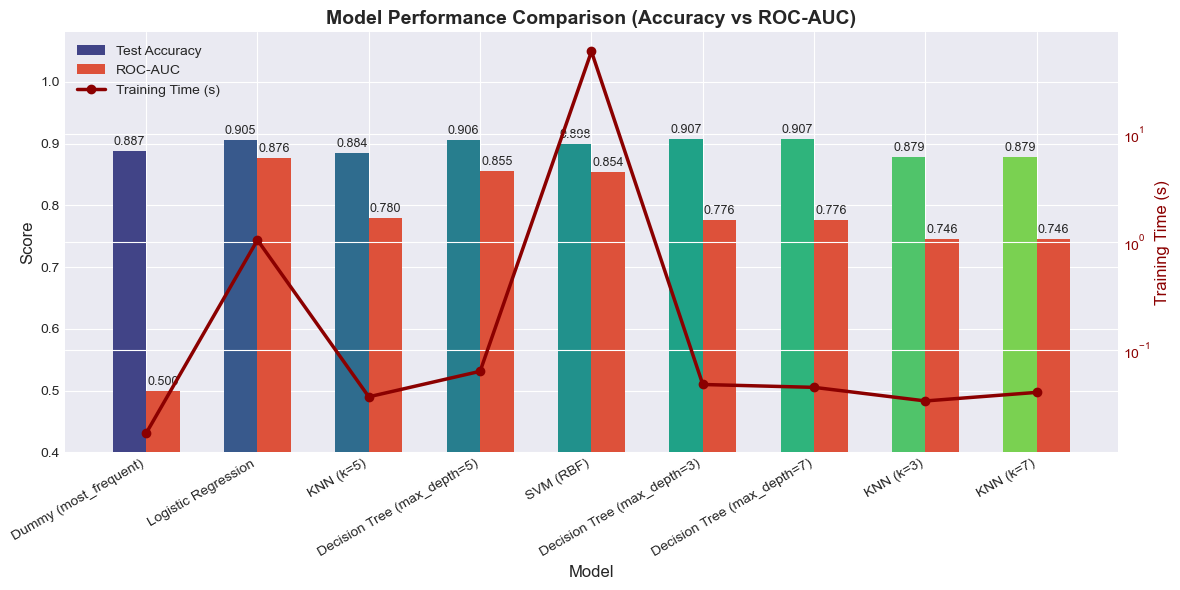

In [170]:
# --- Elegant visualization using existing results_df ---

plt.style.use("seaborn-v0_8-darkgrid")

x = np.arange(len(results_df))
width = 0.3
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars for Accuracy and ROC-AUC
bars1 = ax1.bar(x - width/2, results_df["Test Accuracy"], width, label="Test Accuracy", color=colors)
bars2 = ax1.bar(x + width/2, results_df["ROC-AUC"], width, label="ROC-AUC", color=plt.cm.inferno(0.6))

# --- Add numeric labels above each bar ---
for bar in bars1 + bars2:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

# Customize axes and title
ax1.set_ylabel("Score", fontsize=12)
ax1.set_xlabel("Model", fontsize=12)
ax1.set_title("Model Performance Comparison (Accuracy vs ROC-AUC)", fontsize=14, weight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(results_df["Model"], rotation=30, ha='right')
ax1.set_ylim(0.4, 1.08)
ax1.legend(loc="upper left")

# --- Add Training Time as red line (log scale) ---
ax2 = ax1.twinx()
ax2.plot(x, results_df["Training Time (s)"], color="darkred", marker="o", linewidth=2.5, label="Training Time (s)")
ax2.set_ylabel("Training Time (s)", color="darkred", fontsize=12)
ax2.tick_params(axis='y', labelcolor="darkred")
ax2.set_yscale("log")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()


##### Questions